# **PRACTICAL 1 : Model Training & Evaluation**

Using Colab cache for faster access to the 'diabetes-data-set' dataset.
Dataset Preview:
    Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

✅ Accuracy: 0.7207792207792207

📊 Confusion Matrix:
 [[77 22]
 [21 34]]

📄 Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.78      0.78        99
    

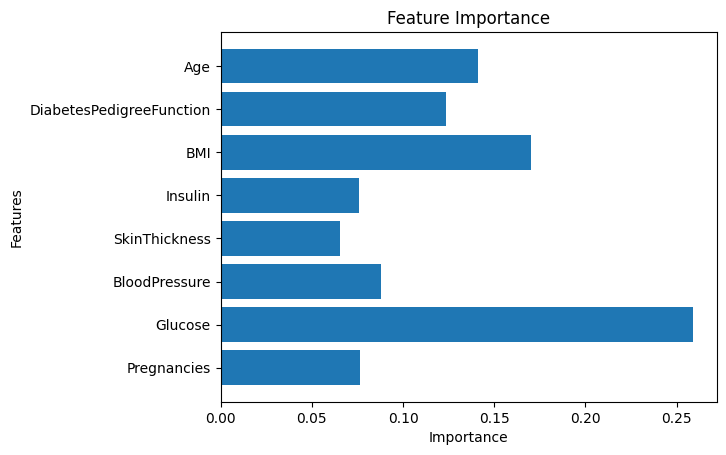

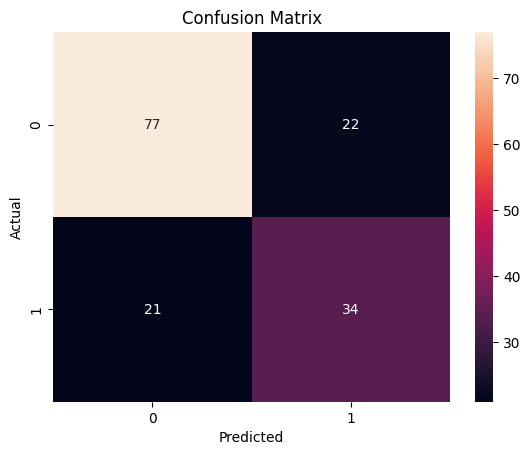

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import os
import kagglehub
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier

# -------------------------------
# 1. Load Dataset
# -------------------------------
path = kagglehub.dataset_download("mathchi/diabetes-data-set")

file = [f for f in os.listdir(path) if f.endswith(".csv")][0]
df = pd.read_csv(os.path.join(path, file))

print("Dataset Preview:\n", df.head())

# -------------------------------
# 2. Features & Target
# -------------------------------
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# -------------------------------
# 3. Train-Test Split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# 4. Model Training
# -------------------------------
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# -------------------------------
# 5. Prediction
# -------------------------------
y_pred = model.predict(X_test)

# -------------------------------
# 6. Evaluation
# -------------------------------
print("\n✅ Accuracy:", accuracy_score(y_test, y_pred))

print("\n📊 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\n📄 Classification Report:\n", classification_report(y_test, y_pred))

# -------------------------------
# 7. Feature Importance
# -------------------------------
importances = model.feature_importances_
features = X.columns

plt.figure()
plt.barh(features, importances)
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Feature Importance")
plt.show()
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# **# PRACTICAL 2 :  PREPROCESSING**

In [ ]:
import pandas as pd, os, kagglehub
from sklearn.preprocessing import LabelEncoder, StandardScaler

path = kagglehub.dataset_download("pavansubhasht/ibm-hr-analytics-attrition-dataset")

file = [f for f in os.listdir(path) if f.endswith(".csv")][0]
df = pd.read_csv(os.path.join(path, file))

# Missing values
df.fillna(method='ffill', inplace=True)

# Encoding
le = LabelEncoder()
for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col])

# Scaling
scaler = StandardScaler()
scaled = scaler.fit_transform(df)

print("Preprocessing Done\n", pd.DataFrame(scaled).head())

Using Colab cache for faster access to the 'ibm-hr-analytics-attrition-dataset' dataset.
Preprocessing Done
          0         1         2         3         4         5         6   \
0  0.446350  2.280906  0.590048  0.742527  1.401512 -1.010909 -0.891688   
1  1.322365 -0.438422 -0.913194 -1.297775 -0.493817 -0.147150 -1.868426   
2  0.008343  2.280906  0.590048  1.414363 -0.493817 -0.887515 -0.891688   
3 -0.429664 -0.438422 -0.913194  1.461466 -0.493817 -0.764121  1.061787   
4 -1.086676 -0.438422  0.590048 -0.524295 -0.493817 -0.887515 -1.868426   

         7    8         9   ...        25   26        27        28        29  \
0 -0.937414  0.0 -1.701283  ... -1.584178  0.0 -0.932014 -0.421642 -2.171982   
1 -0.937414  0.0 -1.699621  ...  1.191438  0.0  0.241988 -0.164511  0.155707   
2  1.316673  0.0 -1.696298  ... -0.658973  0.0 -0.932014 -0.550208  0.155707   
3 -0.937414  0.0 -1.694636  ...  0.266233  0.0 -0.932014 -0.421642  0.155707   
4  0.565311  0.0 -1.691313  ...  1.19143

# **PRACTICAL 3 : HIERARCHICAL CLUSTERING**

100%|██████████| 1.56k/1.56k [00:00<00:00, 2.44MB/s]

Extracting files...


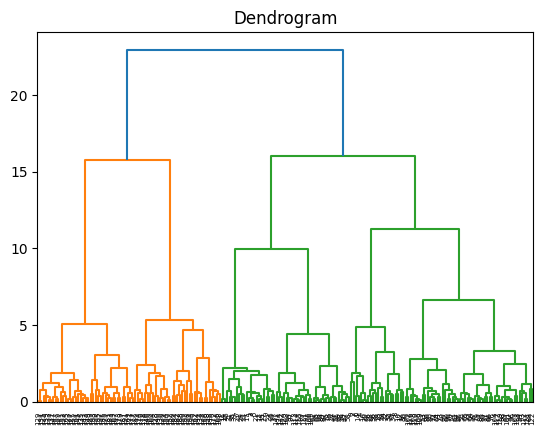

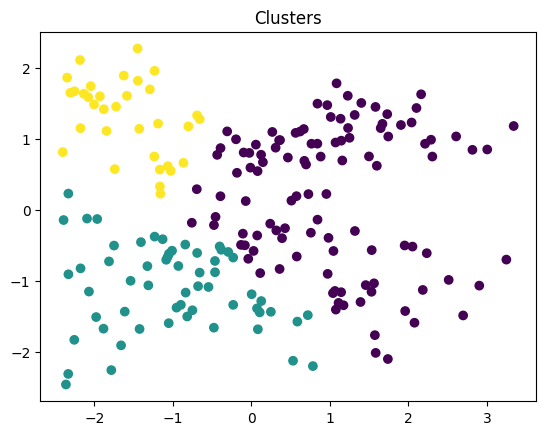

In [ ]:
import pandas as pd, os, kagglehub
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Using a different publicly accessible dataset for customer segmentation
path = kagglehub.dataset_download("kandij/mall-customers")

file = [f for f in os.listdir(path) if f.endswith(".csv")][0]
df = pd.read_csv(os.path.join(path, file))

df = df.select_dtypes(include='number')

X = StandardScaler().fit_transform(df)

# Dendrogram
plt.figure()
dendrogram(linkage(X, method='ward'))
plt.title("Dendrogram")
plt.show()

# Clustering
# For better visualization, let's use 2 principal components if the dataset has more than 2 features
# Otherwise, we'll use the original features.
from sklearn.decomposition import PCA

if X.shape[1] > 2:
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
else:
    X_pca = X

model = AgglomerativeClustering(n_clusters=3)
labels = model.fit_predict(X_pca)

plt.scatter(X_pca[:,0], X_pca[:,1], c=labels)
plt.title("Clusters")
plt.show()

# **Practical 4 : K-Nearest neighbour**

Using Colab cache for faster access to the 'social-network-ads' dataset.

✅ Accuracy: 0.9200

📊 Confusion Matrix:
 [[60  3]
 [ 5 32]]

📄 Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.95      0.94        63
           1       0.91      0.86      0.89        37

    accuracy                           0.92       100
   macro avg       0.92      0.91      0.91       100
weighted avg       0.92      0.92      0.92       100



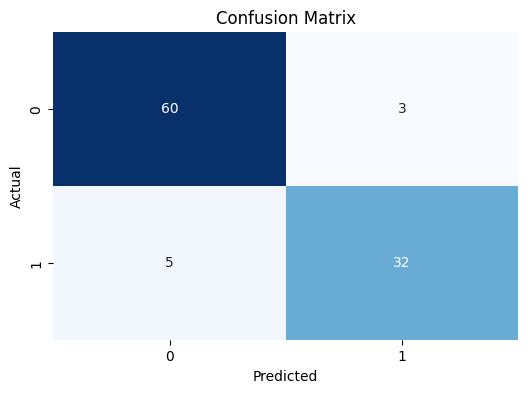

In [ ]:
import pandas as pd
import os
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. Dataset download
path = kagglehub.dataset_download("rakeshrau/social-network-ads")

# 2. Load dataset
file = [f for f in os.listdir(path) if f.endswith(".csv")][0]
df = pd.read_csv(os.path.join(path, file))

# 3. Features & Target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Handle categorical features by encoding 'Gender' column
le = LabelEncoder()
X['Gender'] = le.fit_transform(X['Gender'])

# 4. Scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

# 5. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# 6. Model Training
model = KNeighborsClassifier(n_neighbors=5) # You can experiment with n_neighbors
model.fit(X_train, y_train)

# 7. Prediction
y_pred = model.predict(X_test)

# 8. Evaluation
print(f"\n✅ Accuracy: {accuracy_score(y_test, y_pred):.4f}")

cm = confusion_matrix(y_test, y_pred)
print("\n📊 Confusion Matrix:\n", cm)

print("\n📄 Classification Report:\n", classification_report(y_test, y_pred))

# 9. Visualize Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# **PRACTICAL 5 : Natural Language Processing **


In [ ]:
import pandas as pd
import os
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Ensure NLTK data is downloaded (only needs to be run once)
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')
    nltk.download('punkt')

# 1. Dataset download
path = kagglehub.dataset_download("vishakhdapat/sms-spam-detection-dataset")

# 2. Load dataset
file = [f for f in os.listdir(path) if f.endswith(".csv")][0]
df = pd.read_csv(os.path.join(path, file), encoding='latin-1')

# Drop unnecessary columns and rename for clarity
df = df.iloc[:, [0, 1]]
df.columns = ['target', 'text']

# Convert target to numerical (spam: 1, ham: 0)
df['target'] = df['target'].map({'spam': 1, 'ham': 0})

print("Dataset Preview:\n", df.head())
print("\nTarget Distribution:\n", df['target'].value_counts())


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


100%|██████████| 207k/207k [00:00<00:00, 16.9MB/s]

Extracting files...
Dataset Preview:
    target                                               text
0       0  Go until jurong point, crazy.. Available only ...
1       0                      Ok lar... Joking wif u oni...
2       1  Free entry in 2 a wkly comp to win FA Cup fina...
3       0  U dun say so early hor... U c already then say...
4       0  Nah I don't think he goes to usf, he lives aro...

Target Distribution:
 target
0    4825
1     747
Name: count, dtype: int64


In [ ]:
ps = PorterStemmer()
corpus = []

for i in range(len(df)):
    review = re.sub('[^a-zA-Z]', ' ', df['text'].iloc[i]) # Remove non-alphabetic characters
    review = review.lower() # Convert to lowercase
    review = review.split() # Tokenize
    review = [ps.stem(word) for word in review if not word in stopwords.words('english')] # Remove stopwords and stem
    review = ' '.join(review)
    corpus.append(review)

# 3. Vectorization (TF-IDF)
tfidf = TfidfVectorizer(max_features=2500) # You can adjust max_features
X = tfidf.fit_transform(corpus).toarray()
y = df['target'].values

print("\nShape of vectorized data (X):", X.shape)
print("Shape of target (y):", y.shape)



Shape of vectorized data (X): (5572, 2500)
Shape of target (y): (5572,)


In [ ]:
# 4. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Model Training (Multinomial Naive Bayes)
model = MultinomialNB()
model.fit(X_train, y_train)

# 6. Prediction
y_pred = model.predict(X_test)

# 7. Evaluation
print(f"\n✅ Accuracy: {accuracy_score(y_test, y_pred):.4f}")

cm = confusion_matrix(y_test, y_pred)
print("\n📊 Confusion Matrix:\n", cm)

print("\n📄 Classification Report:\n", classification_report(y_test, y_pred))




✅ Accuracy: 0.9785

📊 Confusion Matrix:
 [[965   0]
 [ 24 126]]

📄 Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       965
           1       1.00      0.84      0.91       150

    accuracy                           0.98      1115
   macro avg       0.99      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115



**PRACTICAL 6 : LINEAR REGRESSION**

Using Colab cache for faster access to the 'student-quiz-marks-dataset' dataset.

--- Model Evaluation ---
✅ R2 Score: 1.0000
📉 Mean Absolute Error (MAE): 0.0212
📈 Mean Squared Error (MSE): 0.0007
📊 Root Mean Squared Error (RMSE): 0.0263


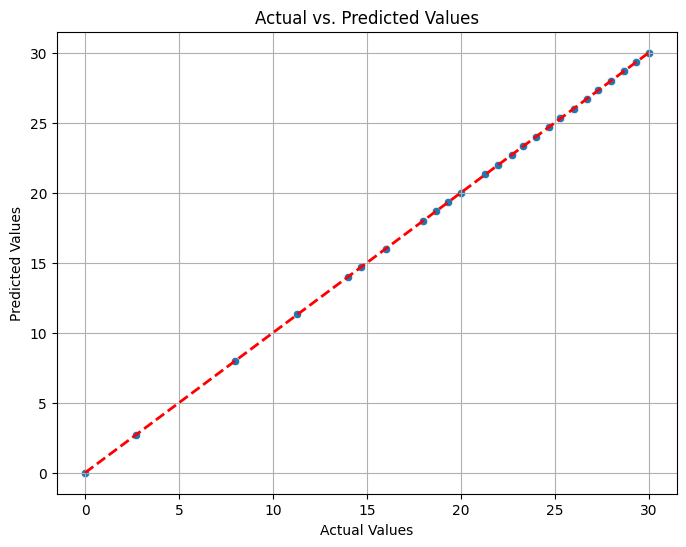

In [ ]:
import pandas as pd
import os
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Dataset download
path = kagglehub.dataset_download("pratsharma7/student-quiz-marks-dataset")

# 2. Load dataset
file = [f for f in os.listdir(path) if f.endswith(".csv")][0]
df = pd.read_csv(os.path.join(path, file))

# 3. Select numeric data
df = df.select_dtypes(include='number')

# Assuming the last column is the target variable
# 4. Features & Target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# 5. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Model Training
model = LinearRegression()
model.fit(X_train, y_train)

# 7. Prediction
y_pred = model.predict(X_test)

# 8. Evaluation Metrics
print("\n--- Model Evaluation ---")
print(f"✅ R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"📉 Mean Absolute Error (MAE): {mean_absolute_error(y_test, y_pred):.4f}")
print(f"📈 Mean Squared Error (MSE): {mean_squared_error(y_test, y_pred):.4f}")
print(f"📊 Root Mean Squared Error (RMSE): {mean_squared_error(y_test, y_pred)**0.5:.4f}")

# 9. Visualization of Predictions
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.title('Actual vs. Predicted Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.grid(True)
plt.show()


# **PRACTICAL 7 : APRIORI**

In [ ]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import os
import kagglehub

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# -------------------------------
# 1. Download Dataset
# -------------------------------
path = kagglehub.dataset_download("heeraldedhia/groceries-dataset")
print("Dataset Path:", path)

# -------------------------------
# 2. Load Dataset
# -------------------------------
files = os.listdir(path)
file_path = [f for f in files if f.endswith(".csv")][0]

df = pd.read_csv(os.path.join(path, file_path))

print("\nDataset Preview:\n", df.head())

# -------------------------------
# 3. Convert to Transactions
# -------------------------------
transactions = []

for _, row in df.iterrows():
    items = [str(item).strip() for item in row if pd.notna(item)]
    transactions.append(items)

print("\nSample Transactions:\n", transactions[:5])

# -------------------------------
# 4. One-Hot Encoding
# -------------------------------
te = TransactionEncoder()
te_data = te.fit(transactions).transform(transactions)

df_encoded = pd.DataFrame(te_data, columns=te.columns_)

print("\nEncoded Data:\n", df_encoded.head())

# -------------------------------
# 5. Apply Apriori
# -------------------------------
frequent_itemsets = apriori(df_encoded, min_support=0.02, use_colnames=True)

print("\nFrequent Itemsets:\n", frequent_itemsets.head())

# -------------------------------
# 6. Association Rules
# -------------------------------
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.3)

print("\nAssociation Rules:\n", rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head())

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Using Colab cache for faster access to the 'groceries-dataset' dataset.
Dataset Path: /kaggle/input/groceries-dataset

Dataset Preview:
    Member_number        Date   itemDescription
0           1808  21-07-2015    tropical fruit
1           2552  05-01-2015        whole milk
2           2300  19-09-2015         pip fruit
3           1187  12-12-2015  other vegetables
4           3037  01-02-2015        whole milk

Sample Transactions:
 [['1808', '21-07-2015', 'tropical fruit'], ['2552', '05-01-2015', 'whole milk'], ['2300', '19-09-2015', 'pip fruit'], ['1187', '12-12-2015', 'other vegetables'], ['3037', '01-02-2015', 'whole milk']]

Encoded Data:
    01-01-2014  01-01-2015  01-02-2014  01-02-2015  01-03-2014  01-03-2015  \
0       False       False       False       False       False       False   
1       False       False       False       False       False       False   
2       False       False       False       False       False       False   
3       False       False       Fa

# **PRACTICAL 8 : BAGGING & BOOSTING**

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import os
import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

# -------------------------------
# 1. Download Dataset
# -------------------------------
path = kagglehub.dataset_download("taweilo/loan-approval-classification-data")
print("Dataset Path:", path)

# -------------------------------
# 2. Load Dataset
# -------------------------------
file = [f for f in os.listdir(path) if f.endswith(".csv")][0]
df = pd.read_csv(os.path.join(path, file))

print("\nDataset Preview:\n", df.head())

# -------------------------------
# 3. Preprocessing
# -------------------------------

# Handle missing values
df.fillna(method='ffill', inplace=True)

# Convert categorical to numeric
for col in df.select_dtypes(include='object'):
    df[col] = df[col].astype('category').cat.codes

# -------------------------------
# 4. Features & Target
# -------------------------------
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# -------------------------------
# 5. Train-Test Split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# 6. Bagging Model (Random Forest)
# -------------------------------
bagging_model = RandomForestClassifier(n_estimators=100, random_state=42)
bagging_model.fit(X_train, y_train)

y_pred_bag = bagging_model.predict(X_test)

# -------------------------------
# 7. Boosting Model (AdaBoost)
# -------------------------------
boosting_model = AdaBoostClassifier(n_estimators=100, random_state=42)
boosting_model.fit(X_train, y_train)

y_pred_boost = boosting_model.predict(X_test)

# -------------------------------
# 8. Evaluation
# -------------------------------
print("\n🔹 Bagging Accuracy:", accuracy_score(y_test, y_pred_bag))
print("🔹 Boosting Accuracy:", accuracy_score(y_test, y_pred_boost))

print("\n📊 Bagging Confusion Matrix:\n", confusion_matrix(y_test, y_pred_bag))
print("\n📊 Boosting Confusion Matrix:\n", confusion_matrix(y_test, y_pred_boost))

100%|██████████| 751k/751k [00:00<00:00, 58.0MB/s]

Extracting files...
Dataset Path: /root/.cache/kagglehub/datasets/taweilo/loan-approval-classification-data/versions/1



Dataset Preview:
    person_age person_gender person_education  person_income  person_emp_exp  \
0        22.0        female           Master        71948.0               0   
1        21.0        female      High School        12282.0               0   
2        25.0        female      High School        12438.0               3   
3        23.0        female         Bachelor        79753.0               0   
4        24.0          male           Master        66135.0               1   

  person_home_ownership  loan_amnt loan_intent  loan_int_rate  \
0                  RENT    35000.0    PERSONAL          16.02   
1                   OWN     1000.0   EDUCATION          11.14   
2              MORTGAGE     5500.0     MEDICAL          12.87   
3                  RENT    35000.0     MEDICAL          15.23   
4                  RENT    35000.0     MEDICAL          14.27   

   loan_percent_income  cb_person_cred_hist_length  credit_score  \
0                 0.49                         